## HW6: Dimensionality Reduction: PCA, Kernel PCA, t-SNE, and UMAP

In this lab, we compare different dimensionality reduction methods and evaluate them.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


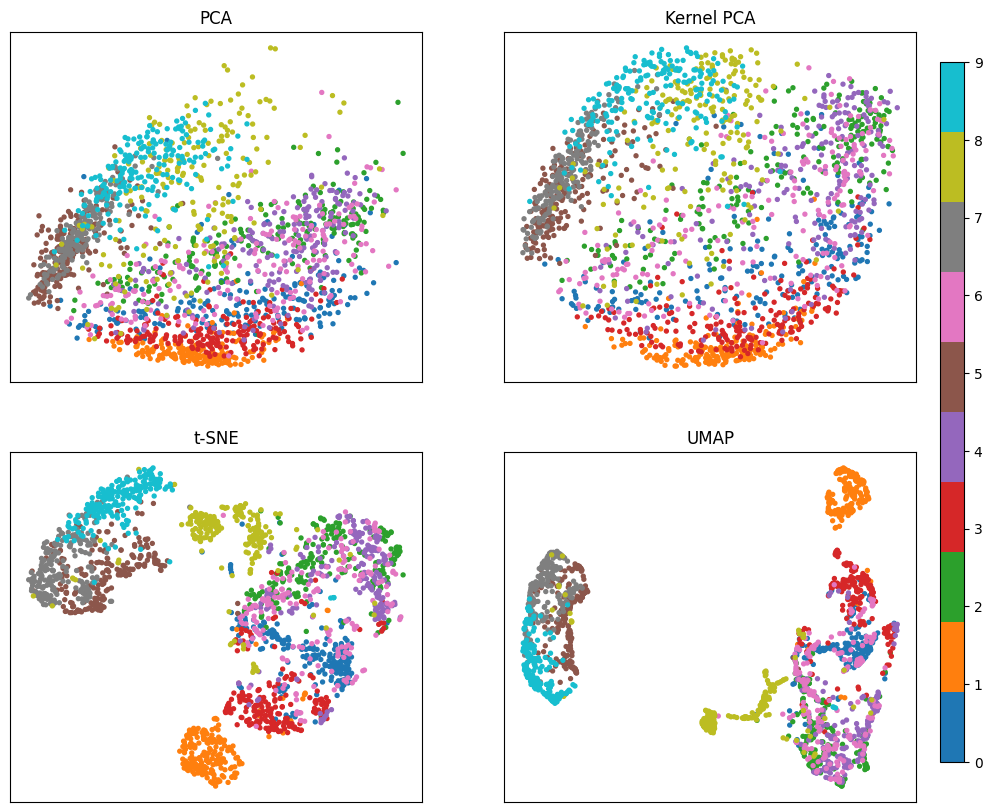

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import umap

# --------------------------------------------------
# Load dataset
# --------------------------------------------------
X, y = fetch_openml("Fashion-MNIST", version=1, return_X_y=True)

X = X.to_numpy().astype(float)
y = y.astype(int)

# ------------------------------------------------
# Balanced sampling (200 per class → 2000 points)
# ------------------------------------------------
np.random.seed(0)

indices = []
for c in range(10):
    class_idx = np.where(y == c)[0]
    indices.extend(np.random.choice(class_idx, 200, replace=False))

indices = np.array(indices)

X = X[indices]
y = y[indices]


# --------------------------------------------------
# Standardize data
# --------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------
# PCA (2D embedding)
# --------------------------------------------------
pca2 = PCA(n_components=2)
Z_pca = pca2.fit_transform(X_scaled)

# --------------------------------------------------
# Kernel PCA
# --------------------------------------------------
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=0.0005)
Z_kpca = kpca.fit_transform(X_scaled)

# --------------------------------------------------
# PCA preprocessing for nonlinear methods
# --------------------------------------------------
pca50 = PCA(n_components=50)
X_pca50 = pca50.fit_transform(X_scaled)

# --------------------------------------------------
# t-SNE
# --------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=50,
    init="pca",
    learning_rate="auto",
    random_state=0
)

Z_tsne = tsne.fit_transform(X_pca50)

# --------------------------------------------------
# UMAP
# --------------------------------------------------
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=0
)

Z_umap = umap_model.fit_transform(X_pca50)

# --------------------------------------------------
# Panel plot (2x2)
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12,10))

plots = [
    (Z_pca, "PCA"),
    (Z_kpca, "Kernel PCA"),
    (Z_tsne, "t-SNE"),
    (Z_umap, "UMAP")
]

for ax, (Z, title) in zip(axes.ravel(), plots):
    sc = ax.scatter(Z[:,0], Z[:,1], c=y, cmap="tab10", s=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

# add space on the right for colorbar
fig.subplots_adjust(right=0.88)

# dedicated colorbar axis
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax)

plt.show()

In [8]:
# Other sample daasets to try: MNIST sample
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import umap

# Load MNIST
X,y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
y = y.astype(int)

# Subsample
np.random.seed(0)
idx = np.random.choice(len(X),2000,replace=False)
X = X[idx]
y = y[idx]

X = StandardScaler().fit_transform(X)

Z_pca = PCA(n_components=2).fit_transform(X)


In [9]:
# Other sample daasets to try: Swiss Roll

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import umap

# Dataset
X,y = make_swiss_roll(n_samples=2000, noise=0.05)

X = StandardScaler().fit_transform(X)

Z_pca = PCA(n_components=2).fit_transform(X)

In [10]:
#Other sample datasets to try: Digits dataset

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import umap

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

# Scale
X = StandardScaler().fit_transform(X)

# PCA
Z_pca = PCA(n_components=2).fit_transform(X)

